In [1]:
from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report, 
    roc_auc_score, RocCurveDisplay, 
    precision_recall_curve, 
    PrecisionRecallDisplay,
    average_precision_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


#---LOAD DATASET---
# fetch dataset 
fertility = fetch_ucirepo(id=244) 
  
# data (as pandas dataframes) 
X = fertility.data.features 
y = fertility.data.targets 

df = pd.concat([X, y], axis=1)

print(df.head(20))
  
# metadata 
#print(fertility.metadata) 

# variable information 
print(fertility.variables) 

df['diagnosis'].value_counts()
df.info()
df.describe()

#---TARGET ENCODING---
# Trasforma target in numerico: 0 = Normal (N), 1 = Altered (O) - one hot encoding
df['diagnosis'] = df['diagnosis'].map({'N': 0, 'O': 1})

    season   age  child_diseases  accident  surgical_intervention  \
0    -0.33  0.69               0         1                      1   
1    -0.33  0.94               1         0                      1   
2    -0.33  0.50               1         0                      0   
3    -0.33  0.75               0         1                      1   
4    -0.33  0.67               1         1                      0   
5    -0.33  0.67               1         0                      1   
6    -0.33  0.67               0         0                      0   
7    -0.33  1.00               1         1                      1   
8     1.00  0.64               0         0                      1   
9     1.00  0.61               1         0                      0   
10    1.00  0.67               1         1                      0   
11    1.00  0.78               1         1                      1   
12    1.00  0.75               1         1                      1   
13    1.00  0.81               1  

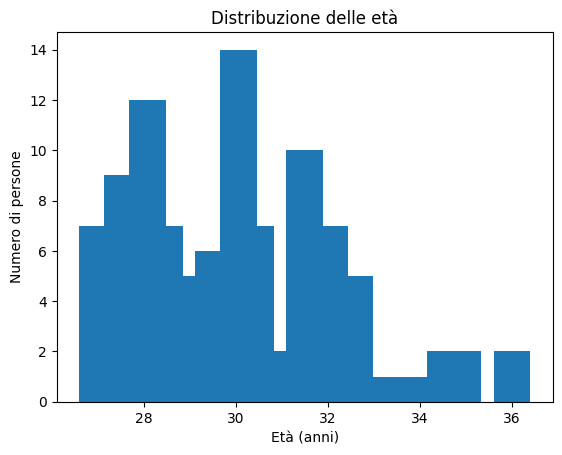

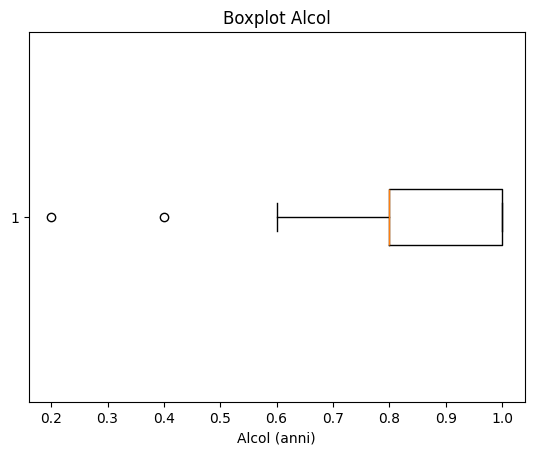

In [2]:
#---EDA---
min_age = 18
max_age = 36

df['age_real'] = df['age'] * (max_age - min_age) + min_age
age_counts = df['age_real'].value_counts().sort_index() # Conta quante persone ci sono per ogni età

# Grafico a barre
plt.bar(age_counts.index, age_counts.values)
plt.xlabel("Età (anni)")
plt.ylabel("Numero di persone")
plt.title("Distribuzione delle età")
plt.show()

# Boxplot
plt.boxplot(df['alcohol'], vert=False)
plt.xlabel("Alcol (anni)")
plt.title("Boxplot Alcol")
plt.show()




===== ALCOHOL =====
diagnosis   0  1
alcohol         
0.2         1  0
0.4         1  0
0.6        15  4
0.8        33  6
1.0        38  2


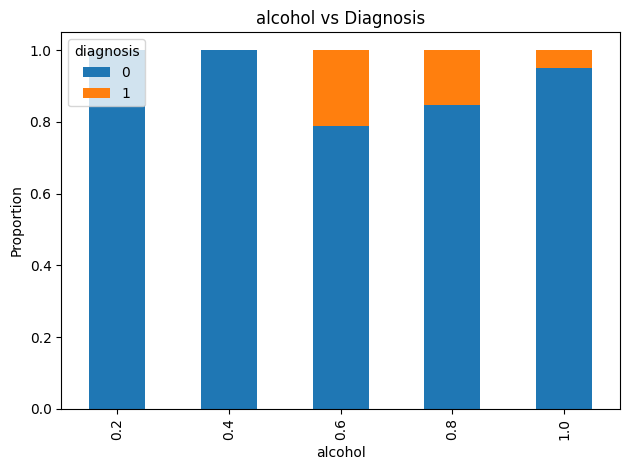


===== SMOKING =====
diagnosis   0  1
smoking         
-1         50  6
 0         20  3
 1         18  3


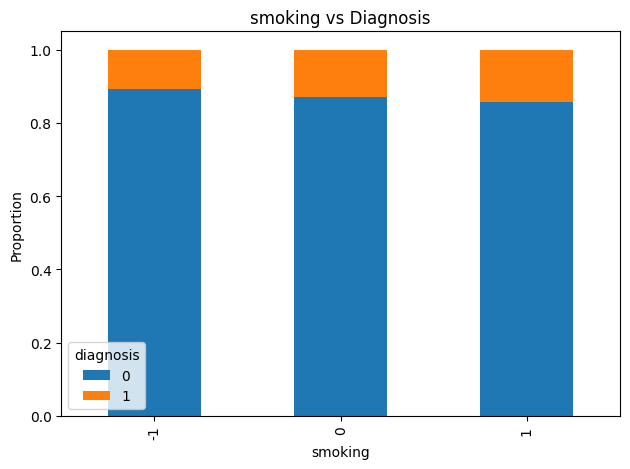


===== HRS_SITTING =====
diagnosis     0  1
hrs_sitting       
0.06          1  1
0.13          1  0
0.19         11  0
0.25         16  1
0.31         10  1
0.38         10  3
0.44          7  2
0.47          1  0
0.50         13  3
0.56          2  0
0.63         10  0
0.75          3  0
0.88          2  1
1.00          1  0


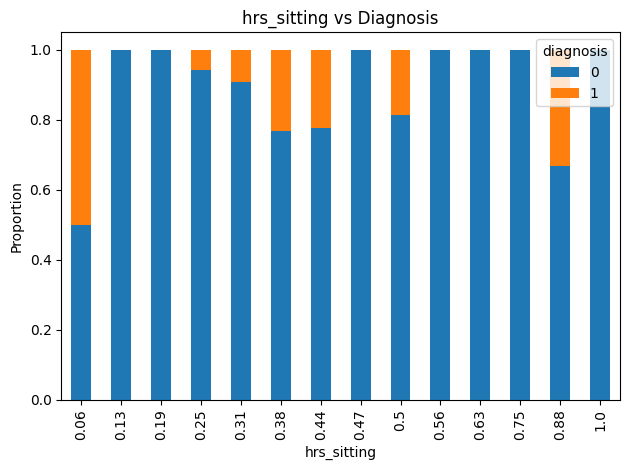

In [3]:
#---FEATURES SELECTION---
# Lista delle features da analizzare
features = ["alcohol", "smoking", "hrs_sitting"]
 
# Ciclo su ciascuna feature per eseguire:
# 1) Tabella di contingenza
# 2) Visualizzazione grafica delle proporzioni
for col in features:
    print(f"\n===== {col.upper()} =====")
 
    # 1) Tabella di contingenza (frequenze assolute)
    # Mostra il numero di osservazioni per ogni combinazione tra la feature corrente e la variabile target (diagnosis)
    table = pd.crosstab(df[col], df["diagnosis"])
    print(table)
 
    # Tabella normalizzata per riga (opzionale)
    table_percent = pd.crosstab(
        df[col], df["diagnosis"], normalize="index"
    )
    table_percent.plot(kind="bar", stacked=True)
    plt.title(f"{col} vs Diagnosis")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.tight_layout()
    plt.show()



===== LOGISTIC REGRESSION =====
              precision    recall  f1-score   support

           0       0.92      0.61      0.73        18
           1       0.12      0.50      0.20         2

    accuracy                           0.60        20
   macro avg       0.52      0.56      0.47        20
weighted avg       0.84      0.60      0.68        20



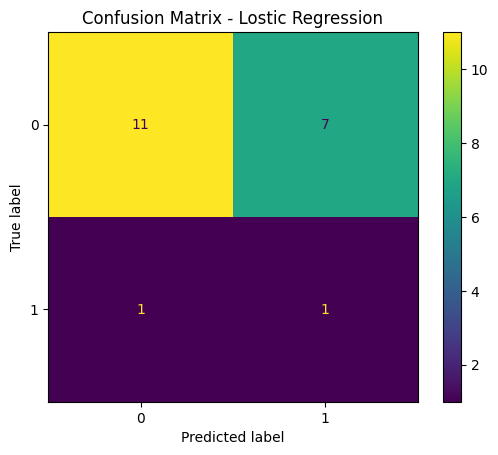

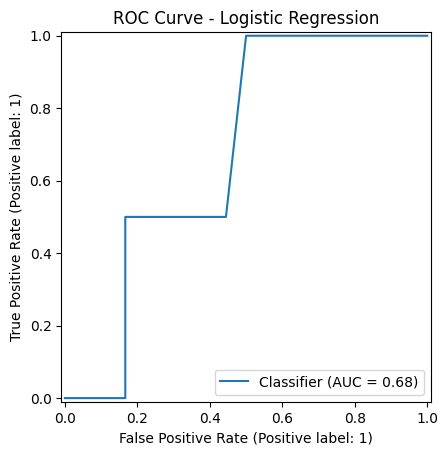

ROC-AUC: 0.6805555555555556


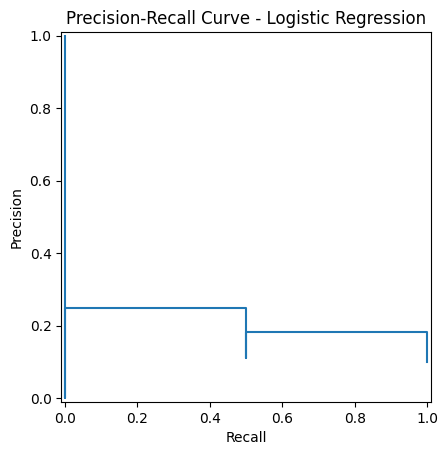

PR-AUC: 0.2159090909090909
Cross-Validation ROC-AUC (mean) Logistic Regression: 0.5238562091503268


In [4]:
# Definire le feature da usare tutte insieme - Multi-feature
#1) Preparazione dei dati
X = df[['alcohol', 'smoking', 'hrs_sitting']]
y = df['diagnosis']
 
# --- Train/Test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
# --- Logistic Regression multifeature ---
log_model = LogisticRegression(class_weight='balanced')
log_model.fit(X_train, y_train)
 
# --- Predizione ---
y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1] #probabilità che il campione sia altered 

print("\n===== LOGISTIC REGRESSION =====")
print(classification_report(y_test, y_pred_log))

# --- Confusion Matrix ---
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Confusion Matrix - Lostic Regression")
plt.show()

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_test, y_proba_log)
plt.title("ROC Curve - Logistic Regression")
plt.show()

# --- Curva roc-auc ---
roc_auc_log = roc_auc_score(y_test, y_proba_log) #contiene le probabilità stimate della classe positiva
print("ROC-AUC:", roc_auc_log)

# --- Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_log)
PrecisionRecallDisplay(precision=precision, recall=recall).plot()
plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

# --- Curva PR-AUC ---
pr_auc_log = average_precision_score(y_test, y_proba_log)
print("PR-AUC:", pr_auc_log)

# --- Cross Validation --- perché dataset è piccolo
cv_scores_log = cross_val_score(
    log_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)
 
print("Cross-Validation ROC-AUC (mean) Logistic Regression:", cv_scores_log.mean())


Odds Ratio:
       Feature  Coefficient  Odds Ratio
0      alcohol    -0.744698    0.474878
1      smoking     0.222181    1.248797
2  hrs_sitting     0.126856    1.135254


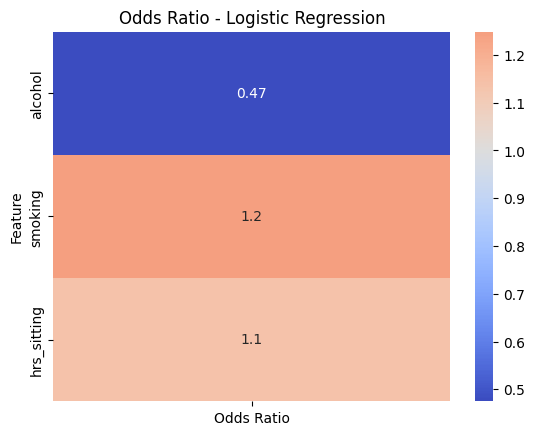

In [5]:
#---INTERPRETAZIONE COEFFICIENTI---
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_model.coef_[0], #forma dell'array dei coefficienti in scikit learn 
    'Odds Ratio': np.exp(log_model.coef_[0]) #log_model.coef() -> array di coefficienti beta della regressione logistica  
})
print("\nOdds Ratio:")
print(coeff_df)

sns.heatmap(
    coeff_df.set_index('Feature')[['Odds Ratio']],
    annot=True,
    cmap="coolwarm",
    center=1
)

plt.title("Odds Ratio - Logistic Regression")
plt.show()

# center=1 --> odds ratio = 1, significa nessun effetto.
# Valori > 1 --> aumento rischio
# Valori < 1--> diminuzione rischio 


===== DECISION TREE =====
              precision    recall  f1-score   support

           0       1.00      0.44      0.62        18
           1       0.17      1.00      0.29         2

    accuracy                           0.50        20
   macro avg       0.58      0.72      0.45        20
weighted avg       0.92      0.50      0.58        20



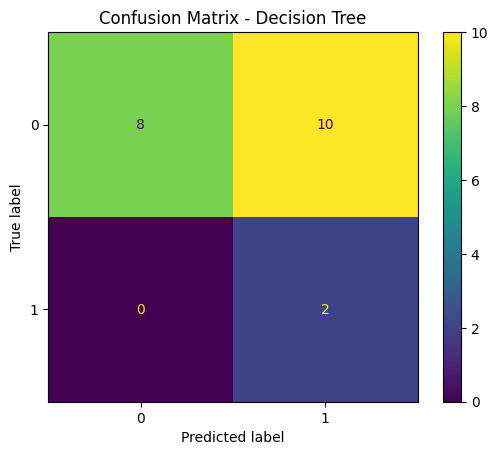

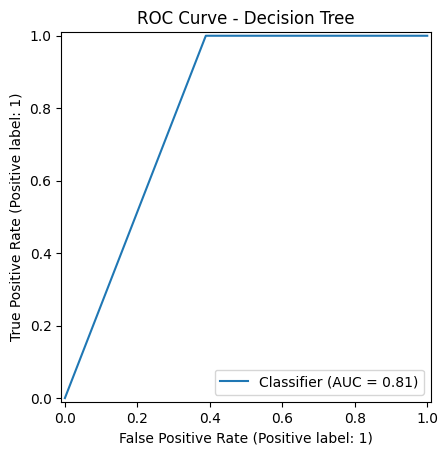

ROC-AUC: 0.8055555555555556


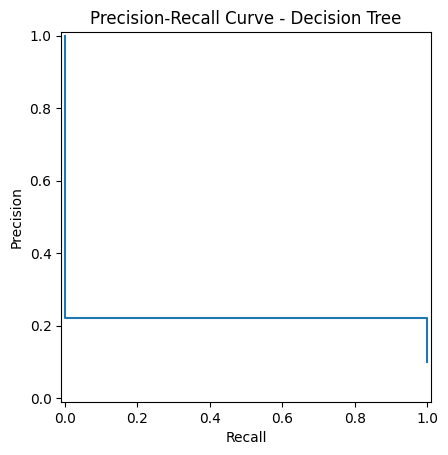

PR-AUC: 0.2222222222222222
Cross-Validation ROC-AUC (mean) Decision Tree: 0.5187908496732027


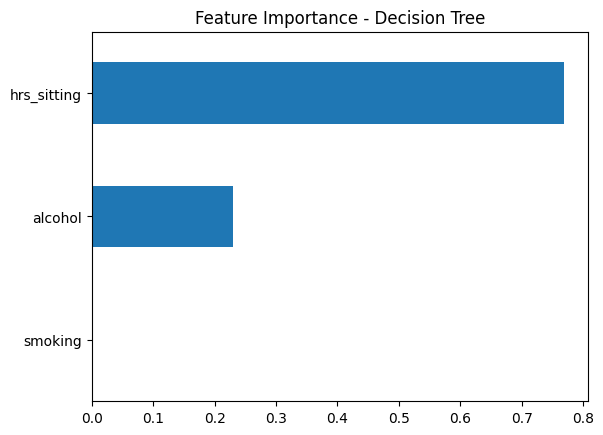

In [6]:
# ---DECISION TREE---
# Crea il modello
dt_model = DecisionTreeClassifier(
                max_depth=3, # profondità massima dell'albero
                criterion='gini', # impurità di Gini (alternativa: 'entropy')
                min_samples_leaf=5, # almeno 5 campioni per foglia (regolarizzazione)
                random_state=42,
                class_weight='balanced'
)

# Addestramento
dt_model.fit(X_train, y_train)

# Predizione
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1] 

print("\n===== DECISION TREE =====")
print(classification_report(y_test, y_pred_dt))
 
# --- Confusion Matrix ---
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_test, y_proba_dt)
plt.title("ROC Curve - Decision Tree")
plt.show()

# --- Curva roc-auc ---
roc_auc_dt = roc_auc_score(y_test, y_proba_dt) #contiene le probabilità stimate della classe positiva
print("ROC-AUC:", roc_auc_dt)

# --- Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_dt)
PrecisionRecallDisplay(precision=precision, recall=recall).plot()
plt.title("Precision-Recall Curve - Decision Tree")
plt.show()

# --- Curva PR-AUC ---
pr_auc_dt = average_precision_score(y_test, y_proba_dt)
print("PR-AUC:", pr_auc_dt)

# --- Cross Validation --- perché dataset è piccolo
cv_scores_dt = cross_val_score(
    dt_model,
    X, 
    y,
    cv=5,
    scoring='roc_auc'
)

print("Cross-Validation ROC-AUC (mean) Decision Tree:", cv_scores_dt.mean())

# --- Feature Importance --- 
importances_dt = pd.Series(dt_model.feature_importances_, index=features)
importances_dt.sort_values().plot(kind='barh')
plt.title("Feature Importance - Decision Tree")
plt.show()

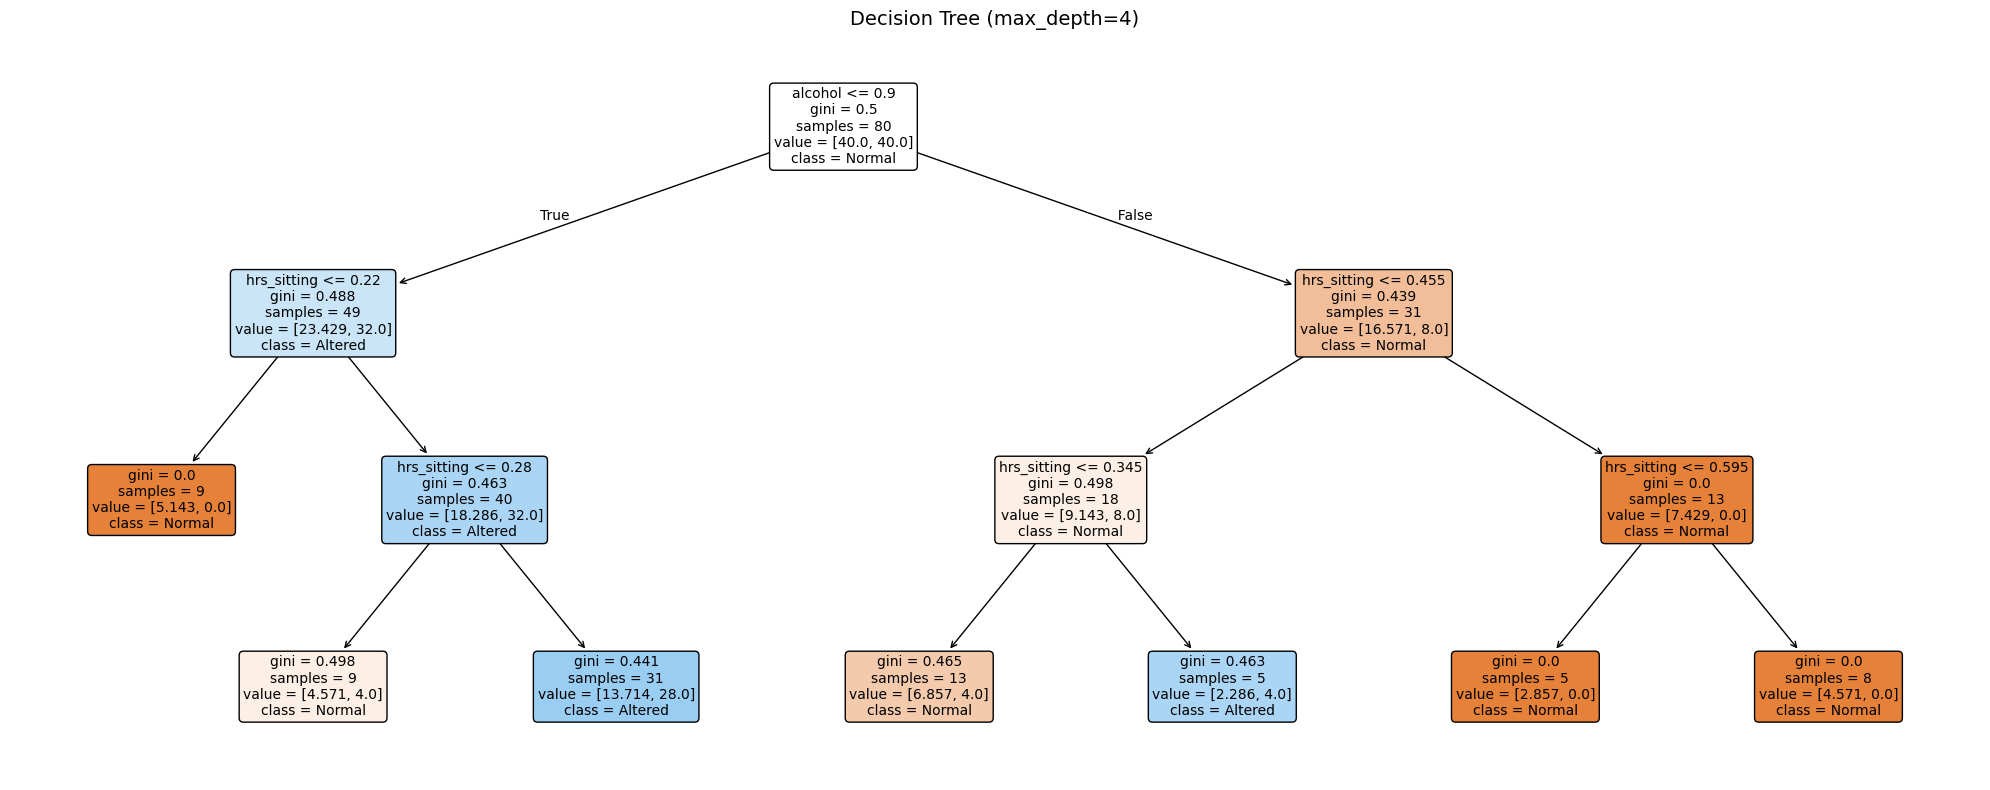

Predizioni su test set: [1 0 1 1 0 0 0 1 0 1 0 1 0 1 1 0 1 1 1 1]


In [7]:
## Visualizzazione dell'Albero
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=features,
    class_names=['Normal', 'Altered'],
    filled=True, # colora i nodi per classe
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (max_depth=4)", fontsize=14)
plt.tight_layout()
plt.show()
y_pred = dt_model.predict(X_test)
print(f"Predizioni su test set: {y_pred}")


===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        18
           1       0.50      1.00      0.67         2

    accuracy                           0.90        20
   macro avg       0.75      0.94      0.80        20
weighted avg       0.95      0.90      0.91        20



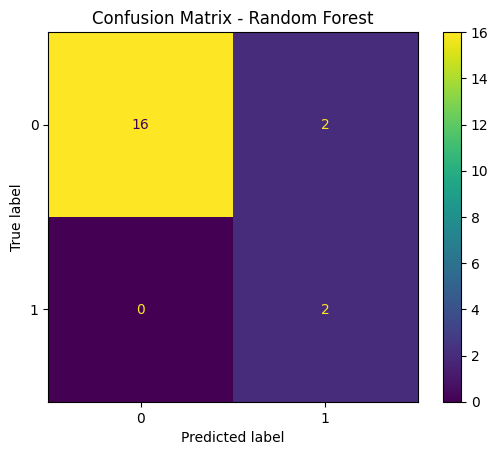

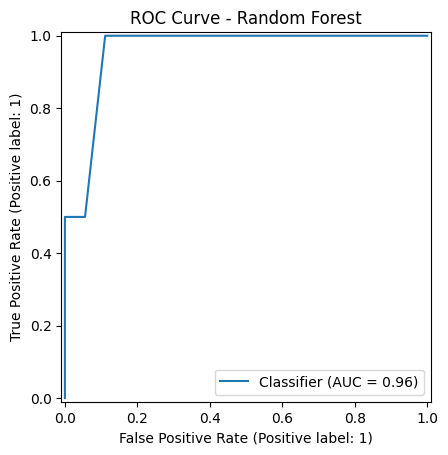

ROC-AUC: 0.9583333333333334


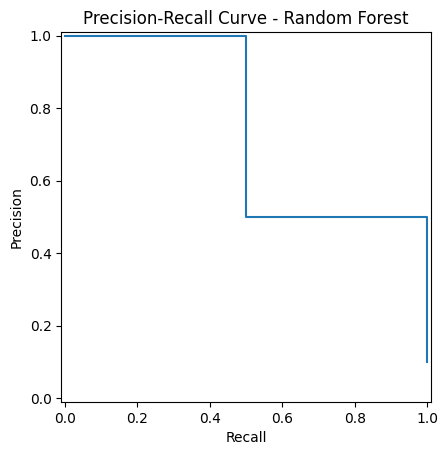

PR-AUC: 0.75
Cross-Validation ROC-AUC (mean) Random Forest: 0.5013071895424838


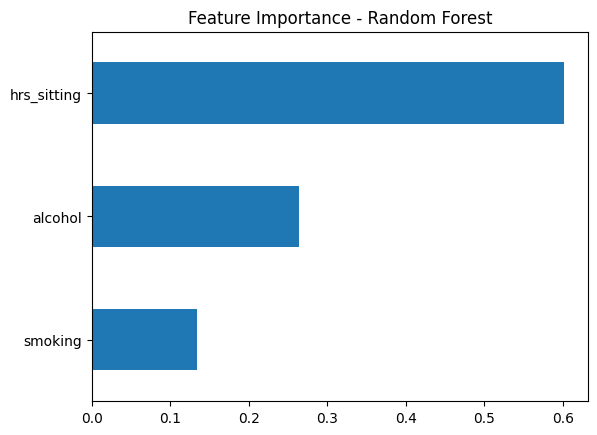

In [8]:
# ---RANDOM FOREST ---
rf_model = RandomForestClassifier(
                n_estimators=200,
                max_depth=4, # profondità massima dell'albero
                class_weight='balanced',
                random_state=42
                
)

# Addestramento
rf_model.fit(X_train, y_train)

# Predizione
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1] 

print("\n===== RANDOM FOREST =====")
print(classification_report(y_test, y_pred_rf))
 
# --- Confusion Matrix ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("ROC Curve - Random Forest")
plt.show()

# --- Curva roc-auc ---
roc_auc_rf = roc_auc_score(y_test, y_proba_rf) #contiene le probabilità stimate della classe positiva
print("ROC-AUC:", roc_auc_rf)

# --- Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf)
PrecisionRecallDisplay(precision=precision, recall=recall).plot()
plt.title("Precision-Recall Curve - Random Forest")
plt.show()

# --- Curva PR-AUC ---
pr_auc_rf = average_precision_score(y_test, y_proba_rf)
print("PR-AUC:", pr_auc_rf)

# --- Cross Validation --- perché dataset è piccolo
cv_scores_rf = cross_val_score(
    rf_model,
    X, 
    y,
    cv=5,
    scoring='roc_auc'
)

print("Cross-Validation ROC-AUC (mean) Random Forest:", cv_scores_rf.mean())

#Se avesse superato o fosse stato uguale a 0.70 allora era un bel modello, qui abbiamo 0.50 quindi equivale a un lancio della moneta

# --- Feature Importance --- 
importances_rf = pd.Series(rf_model.feature_importances_, index=features)
importances_rf.sort_values().plot(kind='barh')
plt.title("Feature Importance - Random Forest")
plt.show()


===== GRADIENT BOOSTING =====
              precision    recall  f1-score   support

           0       0.89      0.94      0.92        18
           1       0.00      0.00      0.00         2

    accuracy                           0.85        20
   macro avg       0.45      0.47      0.46        20
weighted avg       0.81      0.85      0.83        20



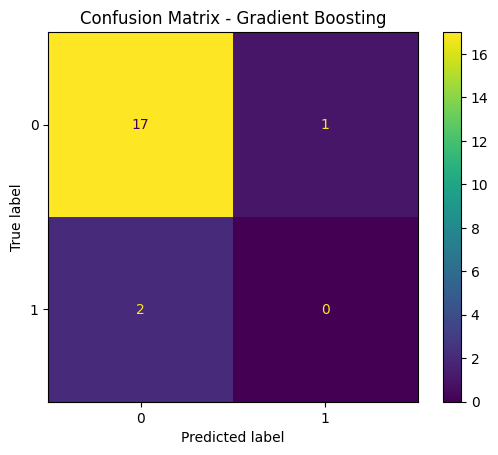

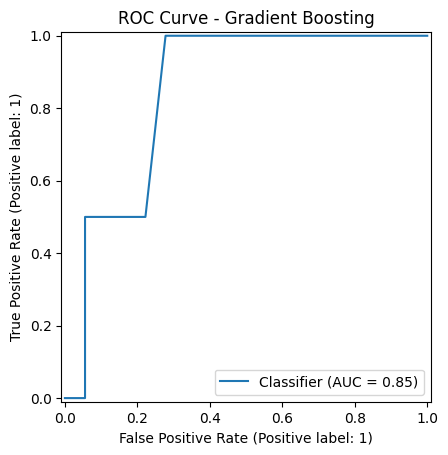

ROC-AUC: 0.8472222222222222


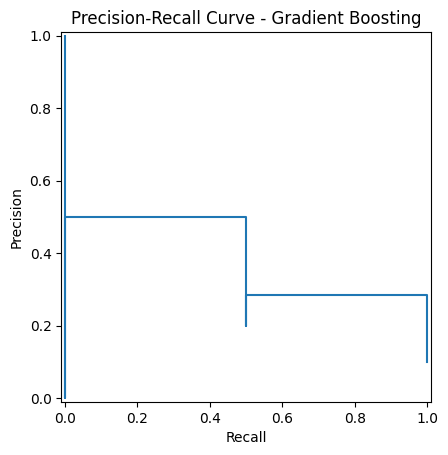

PR-AUC: 0.39285714285714285
Cross-Validation ROC-AUC (mean) Gradient Boosting: 0.5166666666666666


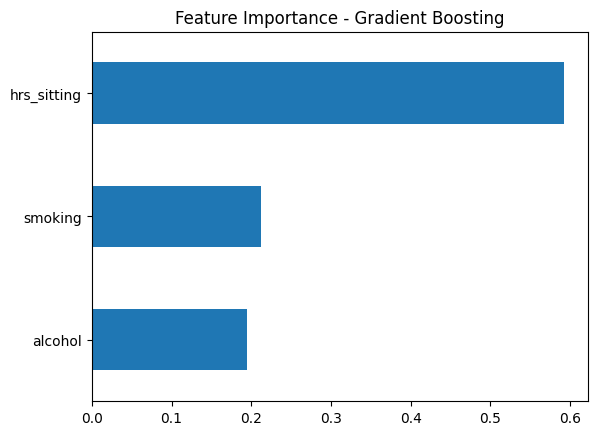

In [9]:
# ---GRADIENT BOOSTING ---
gb_model = GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.1,
                max_depth=4, # profondità massima dell'albero
                random_state=42            
)

# Addestramento
gb_model.fit(X_train, y_train)

# Predizione
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

print("\n===== GRADIENT BOOSTING =====")
print(classification_report(y_test, y_pred_gb))
 
# --- Confusion Matrix ---
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp.plot()
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_test, y_proba_gb)
plt.title("ROC Curve - Gradient Boosting")
plt.show()

# --- Curva roc-auc ---
roc_auc_gb = roc_auc_score(y_test, y_proba_gb) #contiene le probabilità stimate della classe positiva
print("ROC-AUC:", roc_auc_gb)

# --- Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_gb)
PrecisionRecallDisplay(precision=precision, recall=recall).plot()
plt.title("Precision-Recall Curve - Gradient Boosting")
plt.show()

# --- Curva PR-AUC ---
pr_auc_gb = average_precision_score(y_test, y_proba_gb)
print("PR-AUC:", pr_auc_gb)

# --- Cross Validation --- perché dataset è piccolo
cv_scores_gb = cross_val_score(
    gb_model,
    X, 
    y,
    cv=5,
    scoring='roc_auc'
)

print("Cross-Validation ROC-AUC (mean) Gradient Boosting:", cv_scores_gb.mean())

# --- Feature Importance --- 
importances_gb = pd.Series(gb_model.feature_importances_, index=features)
importances_gb.sort_values().plot(kind='barh')
plt.title("Feature Importance - Gradient Boosting")
plt.show()